# Proyecto 1: Análisis de datos Airbnb de la Ciudad de México
## Análisis de datos

## Preguntas de investigación:
1. ¿Cuántos alojamientos hay por alcaldía?¿Cual es la alcaldía con más alojamientos ofertados?
2. ¿Cómo es la distribución espacial? ¿Cómo se concentran estos datos?
1. ¿Cuáles son los tipos de alojamiento? ¿Cuál es el alojamiento más ofertado?
4. ¿Cómo se comporta la distribución de precios (histograma)?
5. ¿Cuál es el precio promedio por tipo de habitación en las diferentes alcaldías?
6. ¿Cómo se relacionan las variables numéricas?


## Meta:
- Usar nuestro conjunto de datos `datos_filtrados.csv` creado en el notebook `Preparacion_datos AIRBNB  2025 listing_18.` para responder a nuestras preguntas de investigación.

## Contexto:
Para este proyecto se usaron los datos del sitio **Insideairbnb** de fecha 05 de noviembre de 2025 para la Ciudad de México, se utilizó la union de archivos tipo Listing.csv, del notebook `UNION  BASES  DATOS` se realizó una limpieza para eliminar los valores atípicos.

---
## Preparar entorno de trabajo.

In [2]:
# Importar bibibliotecas necesarias
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt
import matplotlib.style as style
import folium
from folium.plugins import HeatMap
from pathlib import Path
# sns.set(style="whitegrid")
style.use('ggplot')
from datetime import datetime as dt
hoy = dt.today().strftime("%d-%m-%y")
print(hoy)

13-11-25


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Paso 3: Desarrollo.

In [4]:
# Cargar datos limpios y ver la estructura de datos.  ORIGINAL
df = pd.read_csv('/content/drive/MyDrive/GENTRIFICACION 2025/DATOS AIRBNB /BASE M/listings_filtrado.csv')
df.head()

,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Private room c/ bathroom . Colonia Juarez.,57785,Diego,Cuauhtémoc,19.43035,-99.15511,Private room,478.0,2,0,0.00,2,327
1,"Sunny suite w/ queen size bed, inside boutique...",87973,Diego,Cuauhtémoc,19.44076,-99.16324,Private room,1969.0,1,57,0.52,9,355
2,Couple of Rooms,145672,Edubiel,Tlalpan,19.27215,-99.21848,Private room,1740.0,1,0,0.00,1,365
3,CONDESA HAUS B&B,196253,Condesa Haus Bed & Breakfast CDMX,Cuauhtémoc,19.41006,-99.17645,Private room,1893.0,1,39,0.42,10,334
4,Entire beautiful duplex in la Roma,282620,Nat,Cuauhtémoc,19.42292,-99.15775,Entire home/apt,1625.0,3,39,0.43,1,178


In [ ]:
df[df["host_id"] == 57785]

,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,Private room c/ bathroom . Colonia Juarez.,57785,Diego,Cuauhtémoc,19.430350,-99.155110,Private room,478.0,2,0,0.00,2,327
17929,Private Room c/ bathroom,57785,Diego,Cuauhtémoc,19.432040,-99.156100,Private room,344.0,2,0,0.00,2,0
129298,Room in Roma. Lgbttiq friendly,57785,Diego,Cuauhtémoc,19.409160,-99.164280,Private room,570.0,7,3,0.95,2,70
132232,"Departamento, Colonia Roma.",57785,Diego,Cuauhtémoc,19.409842,-99.165027,Entire home/apt,800.0,5,0,0.00,2,7
152241,Room in Roma. Lgbttiq friendly,57785,Diego,Cuauhtémoc,19.409310,-99.163650,Private room,457.0,10,1,1.00,1,66
170451,Room in Roma. Lgbttiq friendly,57785,Diego,Cuauhtémoc,19.409160,-99.164280,Private room,450.0,4,3,0.51,1,123
190290,Room in Roma. Lgbttiq friendly,57785,Diego,Cuauhtémoc,19.409160,-99.164280,Private room,558.0,4,3,0.33,2,104
192744,"Departamento, Colonia Roma.",57785,Diego,Cuauhtémoc,19.409842,-99.165027,Entire home/apt,800.0,20,0,0.00,2,226


In [5]:
df.shape

(196077, 13)

## 1.1 Total de alojamientos por neighborhood (Alcaldía)

In [6]:
#Total de alojamientos por alcaldía
alojamientos_por_alcaldia = df['neighbourhood'].value_counts()
alojamientos_por_alcaldia

,count
neighbourhood,
Cuauhtémoc,87254
Miguel Hidalgo,32129
Benito Juárez,25741
Coyoacán,13599
Álvaro Obregón,8111
Tlalpan,6117
Venustiano Carranza,5680
Gustavo A. Madero,3710
Cuajimalpa de Morelos,3477


/tmp/ipython-input-1500367608.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x= alojamientos_por_alcaldia, y= alojamientos_por_alcaldia.index, orient='h', palette='viridis')


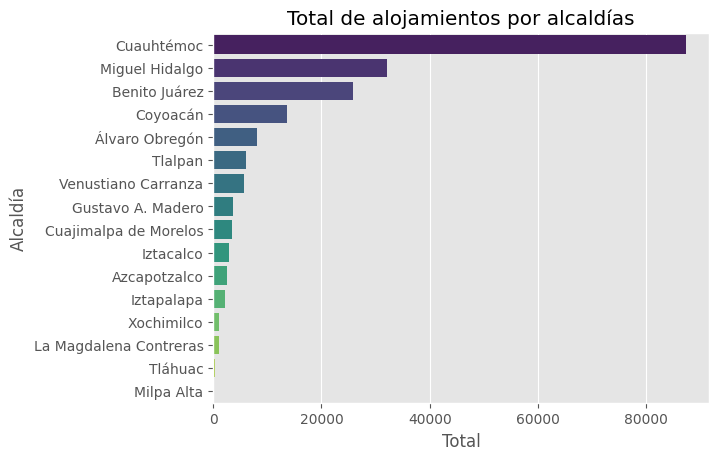

In [7]:
# Gráfica de alojamientos por alcaldía
ax = sns.barplot(x= alojamientos_por_alcaldia, y= alojamientos_por_alcaldia.index, orient='h', palette='viridis')
ax.set_title('Total de alojamientos por alcaldías')
ax.set(xlabel='Total', ylabel='Alcaldía');

## 1.2 Distribución espacial de alojamientos (Mapa de calor)

In [8]:
# Obtener coordenadas para centrar el mapa
media_latitude = df['latitude'].mean()
media_longitude = df['longitude'].mean()
print(media_latitude)
print(media_longitude)

19.40392408384626
-99.16617666679142


In [9]:
# Mapa interactivo
map_folium = folium.Map([19.397890,-99.167112],zoom_start=9, width='100%', height='100%')
HeatMap(df[['latitude','longitude']].dropna(),radius=10).add_to(map_folium)
display(map_folium)

Output hidden; open in https://colab.research.google.com to view.

## 1.3 Tipo de alojamiento mas ofertado

In [ ]:
# Alojamiento más ofertado, suponiendo que cada registro del "host_id " son habitaciones diferentes.
total_por_habitacion = df['room_type'].value_counts()
total_por_habitacion

,count
room_type,
Entire home/apt,123585
Private room,69500
Shared room,2467
Hotel room,525


In [ ]:
#Vamos a calcular la cantidad de habitaciones, departamentos completos, etc diferentes tipos de habitacion
#ofertados por cada "anfitrion", pues puede ser el mismo anfrition con el mismo "host_id", pero con diferentes
#inmuebles a rentar, pero tambien registros que se repiten del mismo "host_id".

import pandas as pd

if {'id','last_scraped'}.issubset(df.columns):
    df = (df.sort_values('last_scraped')  # deja el más reciente
            .drop_duplicates(subset='id', keep='last'))
else:
    df = df.drop_duplicates()

# Normaliza room_type (espacios, nulos)
df['room_type'] = df['room_type'].astype(str).str.strip()
room_order = ['Entire home/apt', 'Private room', 'Shared room', 'Hotel room']

# --- Conteo por host y tipo de habitación ---
host_room_counts = (df
    .groupby(['host_id', 'room_type'], dropna=False)
    .size()
    .unstack(fill_value=0)              # columnas = tipos de room_type
    .reindex(columns=room_order, fill_value=0)
    .astype(int)
)

# Total por host y ordena
host_room_counts['TOTAL'] = host_room_counts.sum(axis=1)
host_room_counts = host_room_counts.sort_values('TOTAL', ascending=False)

host_room_share = (host_room_counts[room_order]
                   .div(host_room_counts['TOTAL'], axis=0)
                   .round(3)
                   .add_suffix('_share'))


room_type  Entire home/apt  Private room  Shared room  Hotel room  TOTAL  \
host_id                                                                    
10764020              1184             0            0           0   1184   
498701635             1076             0            0           0   1076   
333035396              940             8            0           0    948   
16148871               939             0            0           0    939   
91265490               811             0            0           0    811   
245618000              616           132            0           0    748   
207240505                0           429          259           0    688   
50305161               563            10            0           0    573   
27449159               569             0            0           0    569   
302431514              489             0            0           0    489   

room_type  Entire home/apt_share  Private room_share  Shared room_share  \
host_id     

/tmp/ipython-input-3992238420.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['room_type'] = df['room_type'].astype(str).str.strip()


In [ ]:
host_room_counts

room_type,Entire home/apt,Private room,Shared room,Hotel room,TOTAL
host_id,,,,,
7365,9,0,0,0,9
12243,1,1,0,0,2
13693,1,0,0,0,1
24858,6,0,0,0,6
33457,2,0,0,0,2
...,...,...,...,...,...
701708408,0,2,0,0,2
701843199,1,0,0,0,1
702085373,0,1,0,0,1


In [ ]:
# o bien, mas facil usamos un crosstab.
host_room_counts = (pd.crosstab(df['host_id'], df['room_type'])
                      .reindex(columns=room_order, fill_value=0))
host_room_counts['TOTAL'] = host_room_counts.sum(axis=1)


In [ ]:
host_room_counts

room_type,Entire home/apt,Private room,Shared room,Hotel room,TOTAL
host_id,,,,,
7365,9,0,0,0,9
12243,1,1,0,0,2
13693,1,0,0,0,1
24858,6,0,0,0,6
33457,2,0,0,0,2
...,...,...,...,...,...
701708408,0,2,0,0,2
701843199,1,0,0,0,1
702085373,0,1,0,0,1


In [ ]:
room_order = ['Entire home/apt', 'Private room', 'Shared room', 'Hotel room']

# 1) Totales por tipo de habitación
totales_por_habitacion = (
    host_room_counts[room_order]      # solo las 4 columnas de tipos
    .sum(axis=0)                      # suma por columna
    .rename_axis('room_type')
    .to_frame('count')
    .astype(int)
    .sort_values('count', ascending=False)
)

display(totales_por_habitacion)

#Aqui analisamos los registros repetidos de la misma casa.

,count
room_type,
Entire home/apt,122576
Private room,67164
Shared room,2396
Hotel room,517


/tmp/ipython-input-106767619.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x = total_by_room_type.index, y = total_by_room_type, palette='viridis')


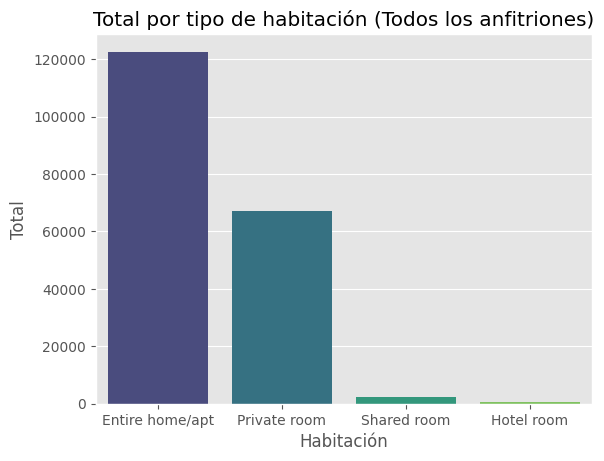

In [ ]:
total_by_room_type = host_room_counts[room_order].sum().sort_values(ascending=False)

ax = sns.barplot(x = total_by_room_type.index, y = total_by_room_type, palette='viridis')
ax.set_title('Total por tipo de habitación (Todos los anfitriones)')
ax.set(ylabel='Total', xlabel= 'Habitación');

/tmp/ipython-input-924795367.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x = total_por_habitacion.index, y = total_por_habitacion, palette='viridis')


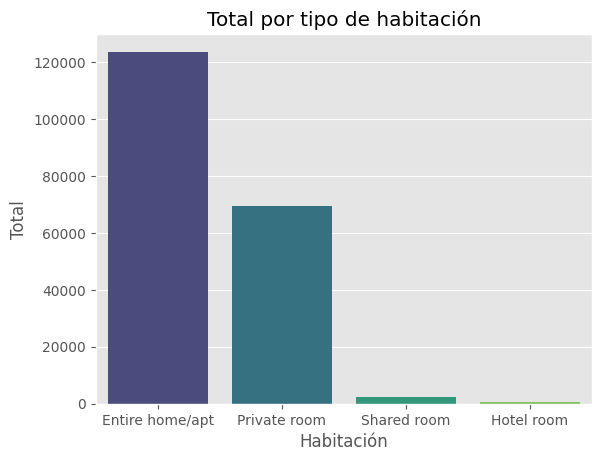

In [ ]:
#Gráfica de alojamiento más ofertado
ax = sns.barplot(x = total_por_habitacion.index, y = total_por_habitacion, palette='viridis')
ax.set_title('Total por tipo de habitación')
ax.set(ylabel='Total', xlabel= 'Habitación');

## 1.4 Distribución de precios por alojamientos

/tmp/ipython-input-3535813361.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x=df['price'], norm_hist=False, bins=50)


<Axes: ylabel='Density'>

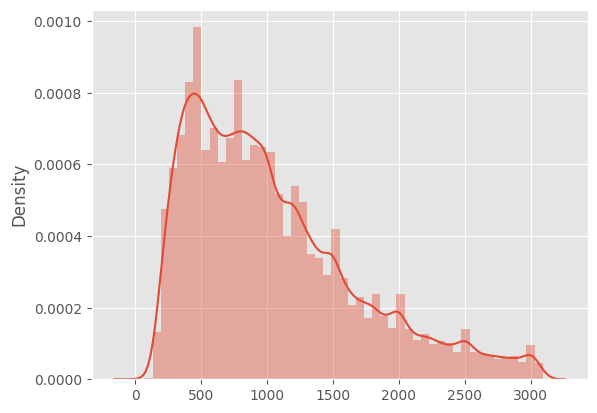

In [ ]:
sns.distplot(x=df['price'], norm_hist=False, bins=50)

In [ ]:
print(f'Curtosis: {kurtosis(df.price)}')
print(f'Asimetría: {skew(df.price)}')

Curtosis: 0.4631556946336479
Asimetría: 0.9968051960314586


In [ ]:
# Resumen de estadísticas precios
df['price'].describe()

,price
count,196077.000000
mean,1049.548264
std,645.329663
min,10.000000
25%,547.000000
50%,900.000000
75%,1399.000000
max,3089.000000


## 1.5 Precios promedio por alcaldía

### 1.5.1 Precio promedio de Entire home/apt por alcaldía
Entire home/apt

In [ ]:
# Filtro y agrupamiento por precio promedio de alojamiento completo
filtro_alojamiento_completo = df['room_type'] == 'Entire home/apt'
df_filtro_alojamiento_completo = df[filtro_alojamiento_completo]
promedio_alojamiento_completo = df_filtro_alojamiento_completo.groupby('neighbourhood')['price'].mean().sort_values(ascending=False)
promedio_alojamiento_completo

,price
neighbourhood,
Miguel Hidalgo,1478.101692
Cuajimalpa de Morelos,1418.465620
Cuauhtémoc,1375.230177
Álvaro Obregón,1140.687297
La Magdalena Contreras,1118.284211
Milpa Alta,1103.038462
Coyoacán,1080.423673
Benito Juárez,1072.450153
Tlalpan,992.160605


/tmp/ipython-input-880722968.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x= promedio_alojamiento_completo, y= promedio_alojamiento_completo.index, orient='h', palette='viridis')


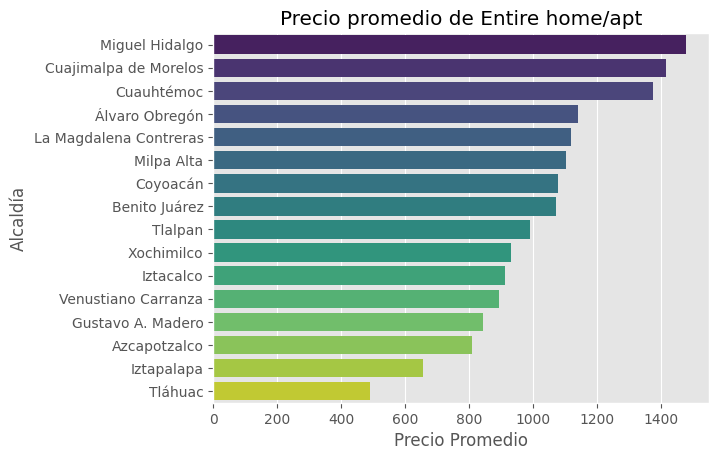

In [ ]:
#Gráfica de alojamiento completo Entire home/apt precio promedio
ax = sns.barplot(x= promedio_alojamiento_completo, y= promedio_alojamiento_completo.index, orient='h', palette='viridis')
ax.set_title('Precio promedio de Entire home/apt')
ax.set(xlabel='Precio Promedio', ylabel='Alcaldía');

### 1.5.2 Precio promedio de Private room por alcaldía
Private room

In [ ]:
# Filtro y agrupamiento por precio promedio de Private room
filtro_alojamiento_privado = df['room_type'] == 'Private room'
df_filtro_alojamiento_privado = df[filtro_alojamiento_privado]
promedio_alojamiento_privado = df_filtro_alojamiento_privado.groupby('neighbourhood')['price'].mean().sort_values(ascending=False)
promedio_alojamiento_privado

,price
neighbourhood,
Cuajimalpa de Morelos,834.256856
Miguel Hidalgo,771.013632
Cuauhtémoc,712.250994
La Magdalena Contreras,684.609576
Álvaro Obregón,648.824661
Coyoacán,608.286761
Iztacalco,606.736885
Benito Juárez,560.847133
Tlalpan,550.680910


/tmp/ipython-input-1347253234.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x= promedio_alojamiento_privado, y= promedio_alojamiento_privado.index, orient='h', palette='viridis')


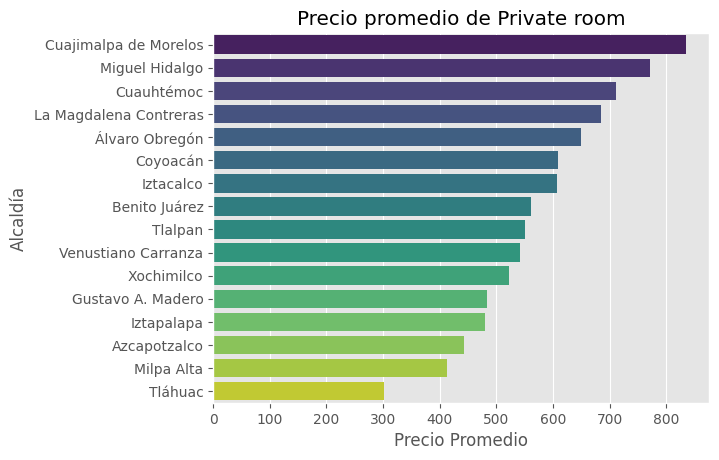

In [ ]:
#Gráfica de alojamiento completo Private room precio promedio
ax = sns.barplot(x= promedio_alojamiento_privado, y= promedio_alojamiento_privado.index, orient='h', palette='viridis')
ax.set_title('Precio promedio de Private room')
ax.set(xlabel='Precio Promedio', ylabel='Alcaldía');

### 1.5.3 Precio promedio de Shared room por alcaldía
Shared room (habitación compartida)

In [ ]:
# Filtro y agrupamiento por precio promedio de alojamiento Shared room
filtro_alojamiento_compartido = df['room_type'] == 'Shared room'
df_filtro_alojamiento_compartido = df[filtro_alojamiento_compartido]
promedio_alojamiento_compartido = df_filtro_alojamiento_compartido.groupby('neighbourhood')['price'].mean().sort_values(ascending=False)
promedio_alojamiento_compartido

,price
neighbourhood,
Cuajimalpa de Morelos,1100.666667
Iztacalco,668.837838
Tláhuac,599.000000
Iztapalapa,550.324324
La Magdalena Contreras,510.375000
Álvaro Obregón,489.229167
Coyoacán,479.617188
Miguel Hidalgo,472.400000
Milpa Alta,472.400000


/tmp/ipython-input-2513010830.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x= promedio_alojamiento_compartido, y= promedio_alojamiento_compartido.index, orient='h', palette='viridis')


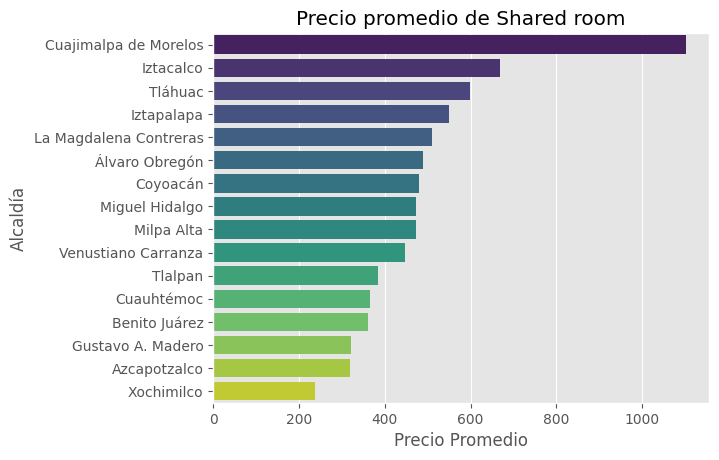

In [ ]:
#Gráfica de alojamiento completo Shared roo precio promedio
ax = sns.barplot(x= promedio_alojamiento_compartido, y= promedio_alojamiento_compartido.index, orient='h', palette='viridis')
ax.set_title('Precio promedio de Shared room')
ax.set(xlabel='Precio Promedio', ylabel='Alcaldía');

### 1.5.4 Precio promedio de Hotel room por alcaldía
Hotel room

In [ ]:
# Filtro y agrupamiento por precio promedio de alojamiento cuarto hotel
filtro_alojamiento_hotel = df['room_type'] == 'Hotel room'
df_filtro_alojamiento_hotel = df[filtro_alojamiento_hotel]
promedio_alojamiento_hotel = df_filtro_alojamiento_hotel.groupby('neighbourhood')['price'].mean().sort_values(ascending=False)
promedio_alojamiento_hotel

,price
neighbourhood,
Coyoacán,1647.818182
Cuajimalpa de Morelos,1499.333333
Álvaro Obregón,1486.559322
Cuauhtémoc,1471.250000
Benito Juárez,1014.230769
Iztacalco,799.250000
Miguel Hidalgo,756.878788


/tmp/ipython-input-273316485.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x= promedio_alojamiento_hotel, y= promedio_alojamiento_hotel.index, orient='h', palette='viridis')


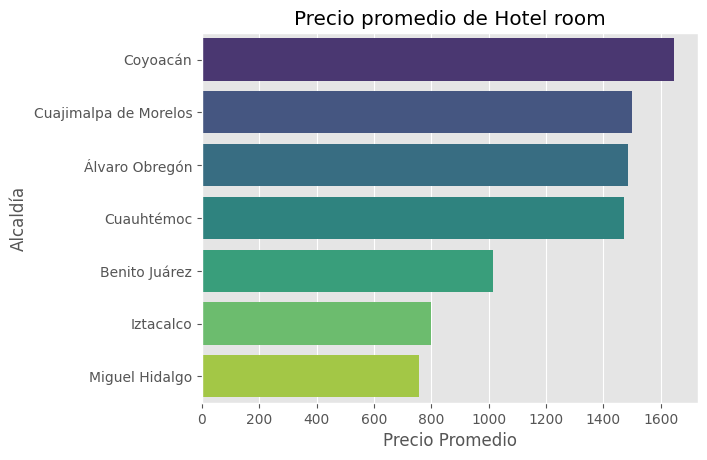

In [ ]:
#Gráfica de alojamiento completo Entire Hotel room precio promedio
ax = sns.barplot(x= promedio_alojamiento_hotel, y= promedio_alojamiento_hotel.index, orient='h', palette='viridis')
ax.set_title('Precio promedio de Hotel room')
ax.set(xlabel='Precio Promedio', ylabel='Alcaldía');

## 1.6 Mapa de calor

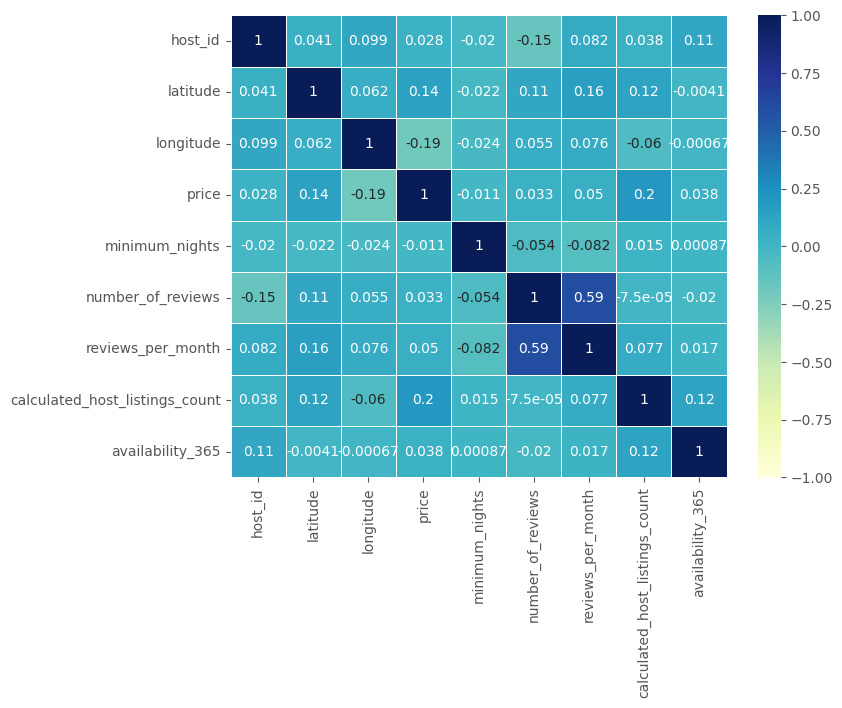

In [ ]:
plt.figure(figsize=(8, 6))
# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include=np.number)
ax = sns.heatmap(numeric_df.corr(), vmin=-1, vmax=1, annot=True, cmap="YlGnBu", linewidths=.5);

## Paso 4: Conclusiones.

- De los datos analizados se contabilizaron 192, 653 lugares ofertados. Las alcaldías con mayor presencia de alojamientos son: en primer lugar se encuentra Cuauhtémoc con 87,254, en segundo lugar esta Miguel Hidalgo con 32,129 y en tercer lugar se encuentra la alcaldía Benito Juárezo con 25,741.


- Se puede notar que los alojamientos se concentran en lugares con mayor desarrollo inmobiliario y disponibilidad de servicios. Habría que analizar la correlación con la distancias de el aeropuerto, estaciones de metro, terminales de autobuses y lugares turísticos.


- El análisis nos muestra que el apartamento y casa completa (Entire home/apt) es el alojamiento más ofertado, seguido de habitación privada (Private room) y en tercer lugar la habitación  compartida (shared room), por último la habitación de hotel (hotel room) con 198 anuncios.


- La distribución de los precios de los alojamientos de Airbnb en la Ciudad de México tiene una distribución con asimetría positiva de un valor 0.996, con una cola ligeramente larga que tiene como curtosis 0.46. El precio promedio es `$1049.54`, los precios tienen un valor mínimo de `$10` y un valor máximo de `$3,089`.

    Los valores atípicos de la variable precios fueron eliminados, había valores de 0 y valores máximos de `$ 1,838,000` que generaban ruido a nuestro conjunto de datos.

- Los precios promedio por tipo de alojamiento resultaron diferentes para las alcaldías:

    Para el caso de habitación y departamento completo la alcaldía Miguel Hidalgo es la más alta con un precio promedio de `$1,478.10` y después le sigue Cuajimalpa de Morelos y Cuauhtémoc con `$1,418.46` y `$1,375.23` respectivamente.

    Para las habitaciones privadas encontramos que Cuajimalpa de Morelos es la más alta con un precio promedio de `$834.25`, Miguel Hidalgo baja a segundo lugar con un valor de `$771` y en tercer lugar se encuentra la alcaldía Cuauhtémoc con un valor de `$712.25`.

    El precio promedio por habitación compartida más alto se encuentra en Cuajimalpa de Morelos con un valor de `$1100.66`, después encontramos valores cerca de los `$550`.

    Y por ultimo la habitación de hotel se reduce a 7 alcaldías con anuncios disponibles, con Cuajimalpa de Morelos con el precio promedio más alto con un valor de `$1647.81`.
    

- Como se observó en el mapa de calor, no hay ninguna relación que se acerque siquiera a una correlación negativa. Hay algunas correlaciones positivas con valores moderados. Las más significativas son las que existen entre las variables 'number_of_reviews’  y ' reviews_per_month' que estamos hablando de una relación de diferentes valores de una misma variable. Habría que probar algún tipo de relación no lineal que no estamos visualizando con este mapa de calor.

